# Bài kiểm tra thực hành — Lập trình phân tích dữ liệu · Buổi 1–5

**Họ và tên:** …………………………  
**MSSV:** …………  
**Lớp:** …………

> Đọc đề trong thư mục `de_thi/`. Làm mỗi câu trong đúng ô bên dưới — có thể thêm ô nếu cần.  
> Trước khi nộp: **Restart & Run All**, lưu file thành `MSSV_HoTen.ipynb`.

In [1]:
import re
import sqlite3
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path('../du_lieu')   # Google Colab: tải 4 tập tin dữ liệu lên rồi đổi thành Path('.')
assert (DATA_DIR / 'giao_dich.csv').exists(), 'Không tìm thấy dữ liệu — kiểm tra lại DATA_DIR'

## Phần A — Python thuần: tập tin văn bản, regex, hàm (2,0 điểm)
*Không dùng pandas và numpy trong phần này.*

### A1 (1,0 đ) Lọc dòng hợp lệ bằng regex · ghi `ca_loi.txt`

In [2]:
# A1
MAU = re.compile(r'(\d{4}-\d{2}-\d{2}) \| (NV\d{3}) \| (CN\d{2}) \| ca=(SANG|CHIEU|TOI)' r' \| vao=(\d{2}:\d{2}) \| ra=(\d{2}:\d{2})')
hop_le, loi = [], []
with open(DATA_DIR/'nhat_ky_ca_lam.txt', 'r', encoding='utf-8-sig') as f:
    for line in f:
        line = line.strip()
        if line.strip() == " " or line.startswith('#'):
            continue
        mau = MAU.fullmatch(line)
        hop_le.append(line) if mau else loi.append(line)
with open('../bai_lam/ca_loi.txt', 'w', encoding='utf-8-sig') as w:
    w.write('\n'.join(loi) + '\n')
print('So dong hop le:', len(hop_le))
print('So dong loi:', len(loi))
print('So ca cua tung loai ca:\n', Counter(MAU.fullmatch(d).group(4) for d in hop_le))

So dong hop le: 724
So dong loi: 52
So ca cua tung loai ca:
 Counter({'SANG': 242, 'CHIEU': 241, 'TOI': 241})


### A2 (1,0 đ) Hàm `thong_ke_di_tre(cac_dong, tre_cho_phep=5, toi_thieu=10)` · nhân viên làm ở đủ 4 chi nhánh

In [3]:
# A2
GIO_BAT_DAU = {'SANG': '07:00', 'CHIEU': '12:00', 'TOI': '17:00'}

def khoang_thoi_gian(hhmm):
    gio, phut = hhmm.split(':')
    return int(gio) * 60 + int(phut)
def thong_ke_di_tre(cac_dong, tre_cho_phep=5, toi_thieu=10):
    ca_tre = Counter()
    tong_ca = Counter()
    for line in cac_dong:
        _, nv, _, ca, vao, _ = MAU.fullmatch(line).groups()
        tong_ca[nv] += 1
        if (khoang_thoi_gian(vao) - khoang_thoi_gian(GIO_BAT_DAU[ca])) > tre_cho_phep:
            ca_tre[nv] +=1
    return {nv: ca_tre[nv] / n for nv, n in tong_ca.items() if n >= toi_thieu }
result = thong_ke_di_tre(hop_le)
if result:
    for nv in sorted(result):
        print(f'{nv}: {result[nv]:.3f}')
print('Nhan vien co ti le di tre cao nhat:', max(result,key=result.get))

chi_nhanh = {}
for d in hop_le:
    _, nv, cn, *_ = MAU.fullmatch(d).groups()
    chi_nhanh.setdefault(nv, set()).add(cn)
print('Làm ở đủ 4 chi nhánh:', sorted(nv for nv, s in chi_nhanh.items() if len(s) == 4))

NV001: 0.097
NV002: 0.081
NV003: 0.088
NV004: 0.280
NV005: 0.111
NV006: 0.087
NV007: 0.146
NV008: 0.059
NV009: 0.200
NV010: 0.036
NV011: 0.156
NV012: 0.160
NV013: 0.077
NV014: 0.031
Nhan vien co ti le di tre cao nhat: NV004
Làm ở đủ 4 chi nhánh: ['NV001', 'NV002', 'NV003', 'NV015']


**Trả lời A2:** Nhân viên có tỉ lệ đi trễ cao nhất là … ; nhân viên làm ở đủ 4 chi nhánh: …

## Phần B — NumPy & lập trình hướng đối tượng (2,0 điểm)

### B1 (0,5 đ) Ma trận doanh thu chi nhánh × ngày

In [4]:
# B1
M = np.array([[18.2, 16.5, 17.1, 19.4, 24.8, 31.2, 29.5],
              [11.4, 10.9, 12.2, 12.8, 15.1, 21.7, 20.3],
              [15.6, 14.8, 15.9, 16.4, 20.2, 26.9, 25.1],
              [ 9.8, 10.2,  9.5, 11.1, 13.6, 18.4, 17.2]])
THU = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']
total_rev = M.sum(axis=1)
average_day = M.mean(axis=0)
max_index, max_value = max(enumerate(total_rev), key=lambda x: x[1]) #dua vao gia tri x[1] de so sanh xem cap nao lon nhat, chu ko dua vao chi so x[0]
print('Tong doanh thu tuan theo tung chi nhanh:', total_rev.round(1))
print('Trung binh theo tung thu:', average_day.round(2))
print(f'Chi nhanh co doanh thu cao nhat: CN{max_index+1}, doanh thu: {max_value}')
#tỉ trọng doanh thu cuối tuần - broadcasting
weekend = M[:, -2:]
rev_weekend = weekend.sum(axis=1)
percent = (rev_weekend / total_rev) * 100
print('Ti trong doanh thu cuoi tuan:', percent)
average_week = M.mean(axis=1,keepdims=True)
print('Doanh thu trung binh theo tung chi nhanh:\n', average_week)
print('So o cua tung chi nhanh co doanh thu > TB tuan:', (M > average_week).sum())


Tong doanh thu tuan theo tung chi nhanh: [156.7 104.4 134.9  89.8]
Trung binh theo tung thu: [13.75 13.1  13.68 14.92 18.42 24.55 23.02]
Chi nhanh co doanh thu cao nhat: CN1, doanh thu: 156.7
Ti trong doanh thu cuoi tuan: [38.73643906 40.22988506 38.54707191 39.64365256]
Doanh thu trung binh theo tung chi nhanh:
 [[22.38571429]
 [14.91428571]
 [19.27142857]
 [12.82857143]]
So o cua tung chi nhanh co doanh thu > TB tuan: 12


### B2 (0,5 đ) Giải hệ phương trình tìm đơn giá nguyên liệu

In [5]:
# B2
hoa_don = np.array([[5,10,2],[3,12,1],[8,6,4]])
thanh_tien = np.array([1470, 1069, 2052])
don_gia = np.linalg.solve(hoa_don, thanh_tien)
bang = pd.Series(don_gia, index=['Cà phê', 'Sữa', 'Đường'])
print('Don gia moi nguyen lieu:\n', bang)

print('Kiem tra lai bang phep nhan ma tran:', np.allclose(hoa_don @ don_gia, thanh_tien))

Don gia moi nguyen lieu:
 Cà phê    220.0
Sữa        32.0
Đường      25.0
dtype: float64
Kiem tra lai bang phep nhan ma tran: True


### B3 (1,0 đ) Lớp `SanPham` và `SanPhamKhuyenMai`

In [6]:
# B3
class SanPham:
    def __init__(self, ma, ten, gia_ban, gia_von):
        self.ma = ma
        self.ten = ten
        self.gia_von = gia_von
        self.gia_ban = gia_ban
    @property
    def gia_ban(self):
        return self._gia_ban
    @gia_ban.setter
    def gia_ban(self, value):
        if value < self.gia_von:
            raise ValueError('Gia ban khong duoc thap hon gia von')
        else:
            self._gia_ban = value
    def gia_thuc_te(self):
        return self.gia_ban
    def bien_loi_nhuan(self):
        return (self.gia_thuc_te() - self.gia_von) / (self.gia_thuc_te())
    def __str__(self):
        return f'{self.ma} {self.ten}: {self.gia_ban} · Bien loi nhuan: {self.bien_loi_nhuan():.2%}'

class SanPhamKhuyenMai(SanPham):
    def __init__(self, ma, ten, gia_ban, gia_von, giam):
        super().__init__(ma, ten, gia_ban, gia_von)
        self.giam = giam
    def gia_thuc_te(self):
        return self.gia_ban * (1 - self.giam)

print(SanPham('SP04', 'Latte', 55000, 18000))
print(SanPhamKhuyenMai('SP11',
'Cookie đá xay', 65000, 22000, 0.20))

try:
    SanPham('SP04', 'Latte', 15000, 18000)
except ValueError:
    print('Gia ban thap hon gia von')
else:
    print('Chinh sua gia tri Latte')



SP04 Latte: 55000 · Bien loi nhuan: 67.27%
SP11 Cookie đá xay: 65000 · Bien loi nhuan: 57.69%
Gia ban thap hon gia von


## Phần C — Pandas: đọc, làm sạch, tích hợp (2,5 điểm)

### C1 (0,5 đ) Đọc CSV, Excel và SQLite

In [7]:
# C1
from pymssql import connect
with sqlite3.connect(DATA_DIR/'san_pham.db') as conn:
    sp = pd.read_sql('SELECT * FROM san_pham', conn)
    cn = pd.read_sql('SELECT * FROM chi_nhanh', conn)
    print('san pham:', sp.shape)
    print('chi nhanh:', cn.shape)
df = pd.read_csv(DATA_DIR/'giao_dich.csv')
df['thoi_gian'] = pd.to_datetime(df['thoi_gian'], format='%d/%m/%Y %H:%M')
khach_hang = pd.read_excel(DATA_DIR/'khach_hang.xlsx', sheet_name='khach_hang')
hang_tv = pd.read_excel(DATA_DIR/'khach_hang.xlsx', sheet_name='hang_thanh_vien')
print('giao dich:', df.shape)
print('khach hang:', khach_hang.shape)
print('hang thanh vien:', hang_tv.shape)
print('So gia tri thieu cua cac cot:\n', df.isna().sum())


san pham: (16, 6)
chi nhanh: (4, 3)
giao dich: (2430, 9)
khach hang: (406, 5)
hang thanh vien: (3, 2)
So gia tri thieu cua cac cot:
 ma_gd              0
thoi_gian          0
ma_cn              0
ma_kh            672
ma_sp              0
so_luong          62
kenh               0
thoi_gian_cho      0
danh_gia         509
dtype: int64


### C2 (1,0 đ) Làm sạch bảng giao dịch theo đúng 5 bước

In [8]:
# C2 — bước 1
df = df.drop_duplicates()
print('So dong con lai sau khi bo trung lap:', len(df))

So dong con lai sau khi bo trung lap: 2400


In [9]:
print(df)

        ma_gd           thoi_gian ma_cn   ma_kh ma_sp  so_luong        kenh  \
0     GD00001 2025-01-01 07:46:00  CN02  KH0201  SP03       1.0    TẠI QUÁN   
1     GD00002 2025-01-01 08:00:00  CN04     NaN  SP01       1.0    Tại quán   
2     GD00003 2025-01-01 08:28:00  CN03  KH0171  SP08       3.0     Mang đi   
3     GD00004 2025-01-01 10:47:00  CN04  KH0162  SP01       3.0    Tại quán   
5     GD00005 2025-01-01 11:40:00  CN01  KH0163  SP03       1.0    Tại quán   
...       ...                 ...   ...     ...   ...       ...         ...   
2425  GD02396 2025-06-30 19:12:00  CN02  KH0075  SP02       1.0   Giao hàng   
2426  GD02397 2025-06-30 19:16:00  CN01  KH0275  SP08       3.0   Giao hàng   
2427  GD02398 2025-06-30 19:39:00  CN02  KH0126  SP07       2.0   Giao hàng   
2428  GD02399 2025-06-30 19:47:00  CN02  KH0139  SP09       4.0   Giao hàng   
2429  GD02400 2025-06-30 20:43:00  CN01  KH0170  SP06       2.0    Tại quán   

      thoi_gian_cho     danh_gia  
0               

In [10]:
# C2 — bước 2
#Tại quán , Mang đi , Giao hàng
kenh = {
    'tại quán': 'Tại quán',   'tai quan': 'Tại quán',
    'mang đi': 'Mang đi',     'mang di': 'Mang đi',
    'giao hàng': 'Giao hàng', 'giao hang': 'Giao hàng',
}
df['kenh'] = df['kenh'].str.strip().str.lower().map(kenh)
print('So luong don theo tung kenh:', df['kenh'].value_counts())

So luong don theo tung kenh: kenh
Tại quán     1029
Mang đi       878
Giao hàng     493
Name: count, dtype: int64


In [11]:
# C2 — bước 3
df = df[~(df['so_luong'] > 20)]
print('So dong con lai cua bang:', len(df))
trung_vi = df.groupby('kenh')['so_luong'].transform('median')
df['so_luong'] = df['so_luong'].fillna(trung_vi).astype('Int64')
print('Trung vi so luong theo kenh:\n', df.groupby('kenh')['so_luong'].median())

So dong con lai cua bang: 2392
Trung vi so luong theo kenh:
 kenh
Giao hàng    2.0
Mang đi      1.0
Tại quán     1.0
Name: so_luong, dtype: Float64


In [12]:
# C2 — bước 4
df.loc[df['thoi_gian_cho'] < 0, 'thoi_gian_cho'] = np.nan

In [13]:
q1 = df.groupby('kenh')['thoi_gian_cho'].transform(lambda s: s.quantile(0.25))   # 5
q3 = df.groupby('kenh')['thoi_gian_cho'].transform(lambda s: s.quantile(0.75))
tren = q3 + 1.5 * (q3 - q1)
ngoai_lai = df['thoi_gian_cho'] > tren
print('Ngoại lai theo kênh:', df.loc[ngoai_lai, 'kenh'].value_counts().to_dict())
df['thoi_gian_cho'] = df['thoi_gian_cho'].clip(tren)
med_channel = df.groupby('kenh')['thoi_gian_cho'].transform('median')
df['thoi_gian_cho'] = df['thoi_gian_cho'].fillna(med_channel)

Ngoại lai theo kênh: {'Tại quán': 37, 'Mang đi': 33, 'Giao hàng': 14}


### C3 (1,0 đ) Tích hợp bốn nguồn · tạo `df`

In [14]:
# C3
sp = sp.rename(columns={'product_id': 'ma_sp'})
print('Gia ban co phai cot dan xuat hay khong?', np.allclose(sp['gia_ban_vat'], sp['gia_ban'] * 1.08, atol=1))
sp = sp.drop(columns='gia_ban_vat')


Gia ban co phai cot dan xuat hay khong? True


In [15]:
print(sp)

   ma_sp            ten_sp    nhom  gia_ban  gia_von
0   SP01        Cà phê đen  Cà phê    29000     9000
1   SP02        Cà phê sữa  Cà phê    35000    11000
2   SP03           Bạc xỉu  Cà phê    39000    12000
3   SP04             Latte  Cà phê    55000    18000
4   SP05         Cold brew  Cà phê    59000    17000
5   SP06           Trà đào     Trà    45000    12000
6   SP07           Trà vải     Trà    45000    13000
7   SP08      Trà sen vàng     Trà    49000    14000
8   SP09    Trà sữa oolong     Trà    52000    16000
9   SP10     Matcha đá xay  Đá xay    62000    21000
10  SP11     Cookie đá xay  Đá xay    65000    22000
11  SP12  Chocolate đá xay  Đá xay    60000    20000
12  SP13         Croissant    Bánh    35000    15000
13  SP14          Tiramisu    Bánh    45000    20000
14  SP15       Bánh mì que    Bánh    25000     9000
15  SP16        Cheesecake    Bánh    49000    22000


In [16]:
print('So ma khach hang bi trung:', khach_hang['ma_kh'].duplicated().sum())
khach_hang = khach_hang.drop_duplicates(subset='ma_kh')
gioi_tinh = {'nam': 'Nam', 'm': 'Nam', 'nữ': 'Nữ', 'nu': 'Nữ', 'f': 'Nữ'}
khach_hang['gioi_tinh'] = khach_hang['gioi_tinh'].str.strip().str.lower().map(gioi_tinh)
ghep = pd.merge(khach_hang, hang_tv, on='hang_thanh_vien', how='left')
no_sp = ~df['ma_sp'].isin(sp['ma_sp'])
print('So dong bi loai:', no_sp.sum())
table = (df[~no_sp]
      .merge(sp, on='ma_sp', how='left', validate='many_to_one')
      .merge(ghep[['ma_kh', 'gioi_tinh', 'hang_thanh_vien', 'chiet_khau']], on='ma_kh', how='left',
             validate='many_to_one')
      .merge(cn, on='ma_cn', how='left'))
table['hang_thanh_vien'] = table['hang_thanh_vien'].fillna('Vãng lai')
table['chiet_khau'] = table['chiet_khau'].fillna(0)
table['doanh_thu'] = table['so_luong'] * table['gia_ban'] * (1 - table['chiet_khau'])
table['loi_nhuan'] = table['doanh_thu'] - table['so_luong'] * table['gia_von']
print('So dong cua bang ghep:', len(table))
print('So giao dich vang lai:', sum(table['hang_thanh_vien'] == 'Vãng lai'))
print(f'Tong doanh thu: {table['doanh_thu'].sum():,}')
print(f'Tong loi nhuan: {table['loi_nhuan'].sum():,}')
print('Doanh thu theo ten chi nhanh:\n', table.groupby('ten_cn')['doanh_thu'].sum().sort_values(ascending=False))

So ma khach hang bi trung: 6
So dong bi loai: 21
So dong cua bang ghep: 2371
So giao dich vang lai: 705
Tong doanh thu: 181,410,850.0
Tong loi nhuan: 120,340,850.0
Doanh thu theo ten chi nhanh:
 ten_cn
Nguyễn Huệ    57392650.0
Hoàn Kiếm     47930750.0
Thảo Điền     40784000.0
Cầu Giấy      35303450.0
Name: doanh_thu, dtype: Float64


## Phần D — Biến đổi & thu gọn dữ liệu (1,5 điểm)

### D1 (0,75 đ) Mã hoá, biến đổi log, one-hot

In [17]:
print(table.columns.to_list())
print(table.head().to_string())

['ma_gd', 'thoi_gian', 'ma_cn', 'ma_kh', 'ma_sp', 'so_luong', 'kenh', 'thoi_gian_cho', 'danh_gia', 'ten_sp', 'nhom', 'gia_ban', 'gia_von', 'gioi_tinh', 'hang_thanh_vien', 'chiet_khau', 'ten_cn', 'thanh_pho', 'doanh_thu', 'loi_nhuan']
     ma_gd           thoi_gian ma_cn   ma_kh ma_sp  so_luong      kenh  thoi_gian_cho danh_gia        ten_sp    nhom  gia_ban  gia_von gioi_tinh hang_thanh_vien  chiet_khau      ten_cn    thanh_pho  doanh_thu  loi_nhuan
0  GD00001 2025-01-01 07:46:00  CN02  KH0201  SP03         1  Tại quán          12.30  Rất tốt       Bạc xỉu  Cà phê    39000    12000        Nữ             Bạc        0.05   Thảo Điền  Hồ Chí Minh    37050.0    25050.0
1  GD00002 2025-01-01 08:00:00  CN04     NaN  SP01         1  Tại quán          12.30      Tốt    Cà phê đen  Cà phê    29000     9000       NaN        Vãng lai        0.00    Cầu Giấy       Hà Nội    29000.0    20000.0
2  GD00003 2025-01-01 08:28:00  CN03  KH0171  SP08         3   Mang đi           9.35  Rất tốt  Trà sen và

In [18]:
# D1
import scipy.stats as scp
import math
table=table.rename(columns={'danh_gia': 'diem_dg'})
danh_gia = {
    'Rất tệ': 1,
    'Tệ': 2,
    'Bình thường': 3,
    'Tốt': 4,
    'Rất tốt': 5
}
table['diem_dg'] = table['diem_dg'].astype(str).str.strip().map(danh_gia)
mode = table['diem_dg'].mode()
mode_value = mode[0] if not mode.empty else 3
table['diem_dg'] = table['diem_dg'].fillna(mode_value).astype(int)
print(table['diem_dg'])

table['log_cho'] = np.log1p(table['thoi_gian_cho'])
print(table['log_cho'])

print('Do lech cua thoi_gian_cho truoc bien doi:', scp.skew(table['thoi_gian_cho'],nan_policy='omit').round(3))
print('Do lech cua thoi_gian_cho truoc bien doi:', scp.skew(table['log_cho'], nan_policy='omit').round(3)) #lo di cac o bi NaN va tinh  tren cac dong khac

#default: propagate(lan truyen)

0       5
1       4
2       5
3       4
4       4
       ..
2366    2
2367    3
2368    3
2369    5
2370    4
Name: diem_dg, Length: 2371, dtype: int64
0       2.587764
1       2.587764
2       2.336987
3       2.587764
4       2.587764
          ...   
2366    3.843476
2367    3.843476
2368    3.843476
2369    3.843476
2370    2.587764
Name: log_cho, Length: 2371, dtype: float64
Do lech cua thoi_gian_cho truoc bien doi: 1.433
Do lech cua thoi_gian_cho truoc bien doi: 1.303


In [19]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit_transform(table[['kenh']])
ohe.get_feature_names_out()

array(['kenh_Giao hàng', 'kenh_Mang đi', 'kenh_Tại quán'], dtype=object)

### D2 (0,75 đ) Bảng đặc trưng khách hàng · tương quan · PCA

In [26]:
# D2
thanh_vien = table[table['hang_thanh_vien'] != 'Vãng lai']
khach = thanh_vien.groupby('ma_kh').agg(
    so_gd = ('ma_gd', 'count'),
    tong_chi = ('doanh_thu', 'sum'),
    sl_tb = ('so_luong', 'mean'),
    cho_tb = ('thoi_gian_cho', 'mean'),
    diem_tb = ('diem_dg', 'mean'),
    ti_le_giao = ('kenh', lambda x: (x=='Giao hàng').mean())
)

print('Kich thuoc bang khach:', khach.shape)
khach['tong_chi'] = pd.qcut(khach['tong_chi'], q=3, labels=['Thấp', 'Vừa', 'Cao'])
print(khach['tong_chi'].value_counts())

so = table.select_dtypes(include='number')
print('So luong cac cot so:', so.shape[1])
correlation = so.corr()
print(correlation.to_string())

Kich thuoc bang khach: (396, 6)
tong_chi
Thấp    132
Vừa     132
Cao     132
Name: count, dtype: int64
So luong cac cot so: 9
               so_luong  thoi_gian_cho   diem_dg   gia_ban   gia_von  chiet_khau  doanh_thu  loi_nhuan   log_cho
so_luong       1.000000       0.202228 -0.068202  0.004305 -0.001338    0.224797   0.872046   0.857181  0.199515
thoi_gian_cho  0.202228       1.000000 -0.363000  0.010146 -0.016286   -0.031012   0.187374   0.194646  0.993705
diem_dg       -0.068202      -0.363000  1.000000 -0.013903 -0.002808    0.028613  -0.070871  -0.073895 -0.360372
gia_ban        0.004305       0.010146 -0.013903  1.000000  0.859127   -0.015908   0.433713   0.434897  0.010591
gia_von       -0.001338      -0.016286 -0.002808  0.859127  1.000000   -0.009573   0.369712   0.310465 -0.014693
chiet_khau     0.224797      -0.031012  0.028613 -0.015908 -0.009573    1.000000   0.118743   0.080745 -0.032228
doanh_thu      0.872046       0.187374 -0.070871  0.433713  0.369712    0.118743   

**Trả lời D2:** Cặp đặc trưng dư thừa là … vì … ; PCA cần … thành phần để giữ ít nhất 90% phương sai.

## Phần E — Trực quan hoá (2,0 điểm)

In [21]:
print(table.head().to_string())
theo_thang = (table.groupby([table['thoi_gian'].dt.month, 'kenh'])['doanh_thu'].sum() / 1e6).unstack()


     ma_gd           thoi_gian ma_cn   ma_kh ma_sp  so_luong      kenh  thoi_gian_cho  diem_dg        ten_sp    nhom  gia_ban  gia_von gioi_tinh hang_thanh_vien  chiet_khau      ten_cn    thanh_pho  doanh_thu  loi_nhuan   log_cho
0  GD00001 2025-01-01 07:46:00  CN02  KH0201  SP03         1  Tại quán          12.30        5       Bạc xỉu  Cà phê    39000    12000        Nữ             Bạc        0.05   Thảo Điền  Hồ Chí Minh    37050.0    25050.0  2.587764
1  GD00002 2025-01-01 08:00:00  CN04     NaN  SP01         1  Tại quán          12.30        4    Cà phê đen  Cà phê    29000     9000       NaN        Vãng lai        0.00    Cầu Giấy       Hà Nội    29000.0    20000.0  2.587764
2  GD00003 2025-01-01 08:28:00  CN03  KH0171  SP08         3   Mang đi           9.35        5  Trà sen vàng     Trà    49000    14000       Nam            Vàng        0.10   Hoàn Kiếm       Hà Nội   132300.0    90300.0  2.336987
3  GD00004 2025-01-01 10:47:00  CN04  KH0162  SP01         3  Tại quán          

/var/folders/wn/_4rdp5jj49g1nj7l8z3b20600000gn/T/ipykernel_71511/2786286413.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


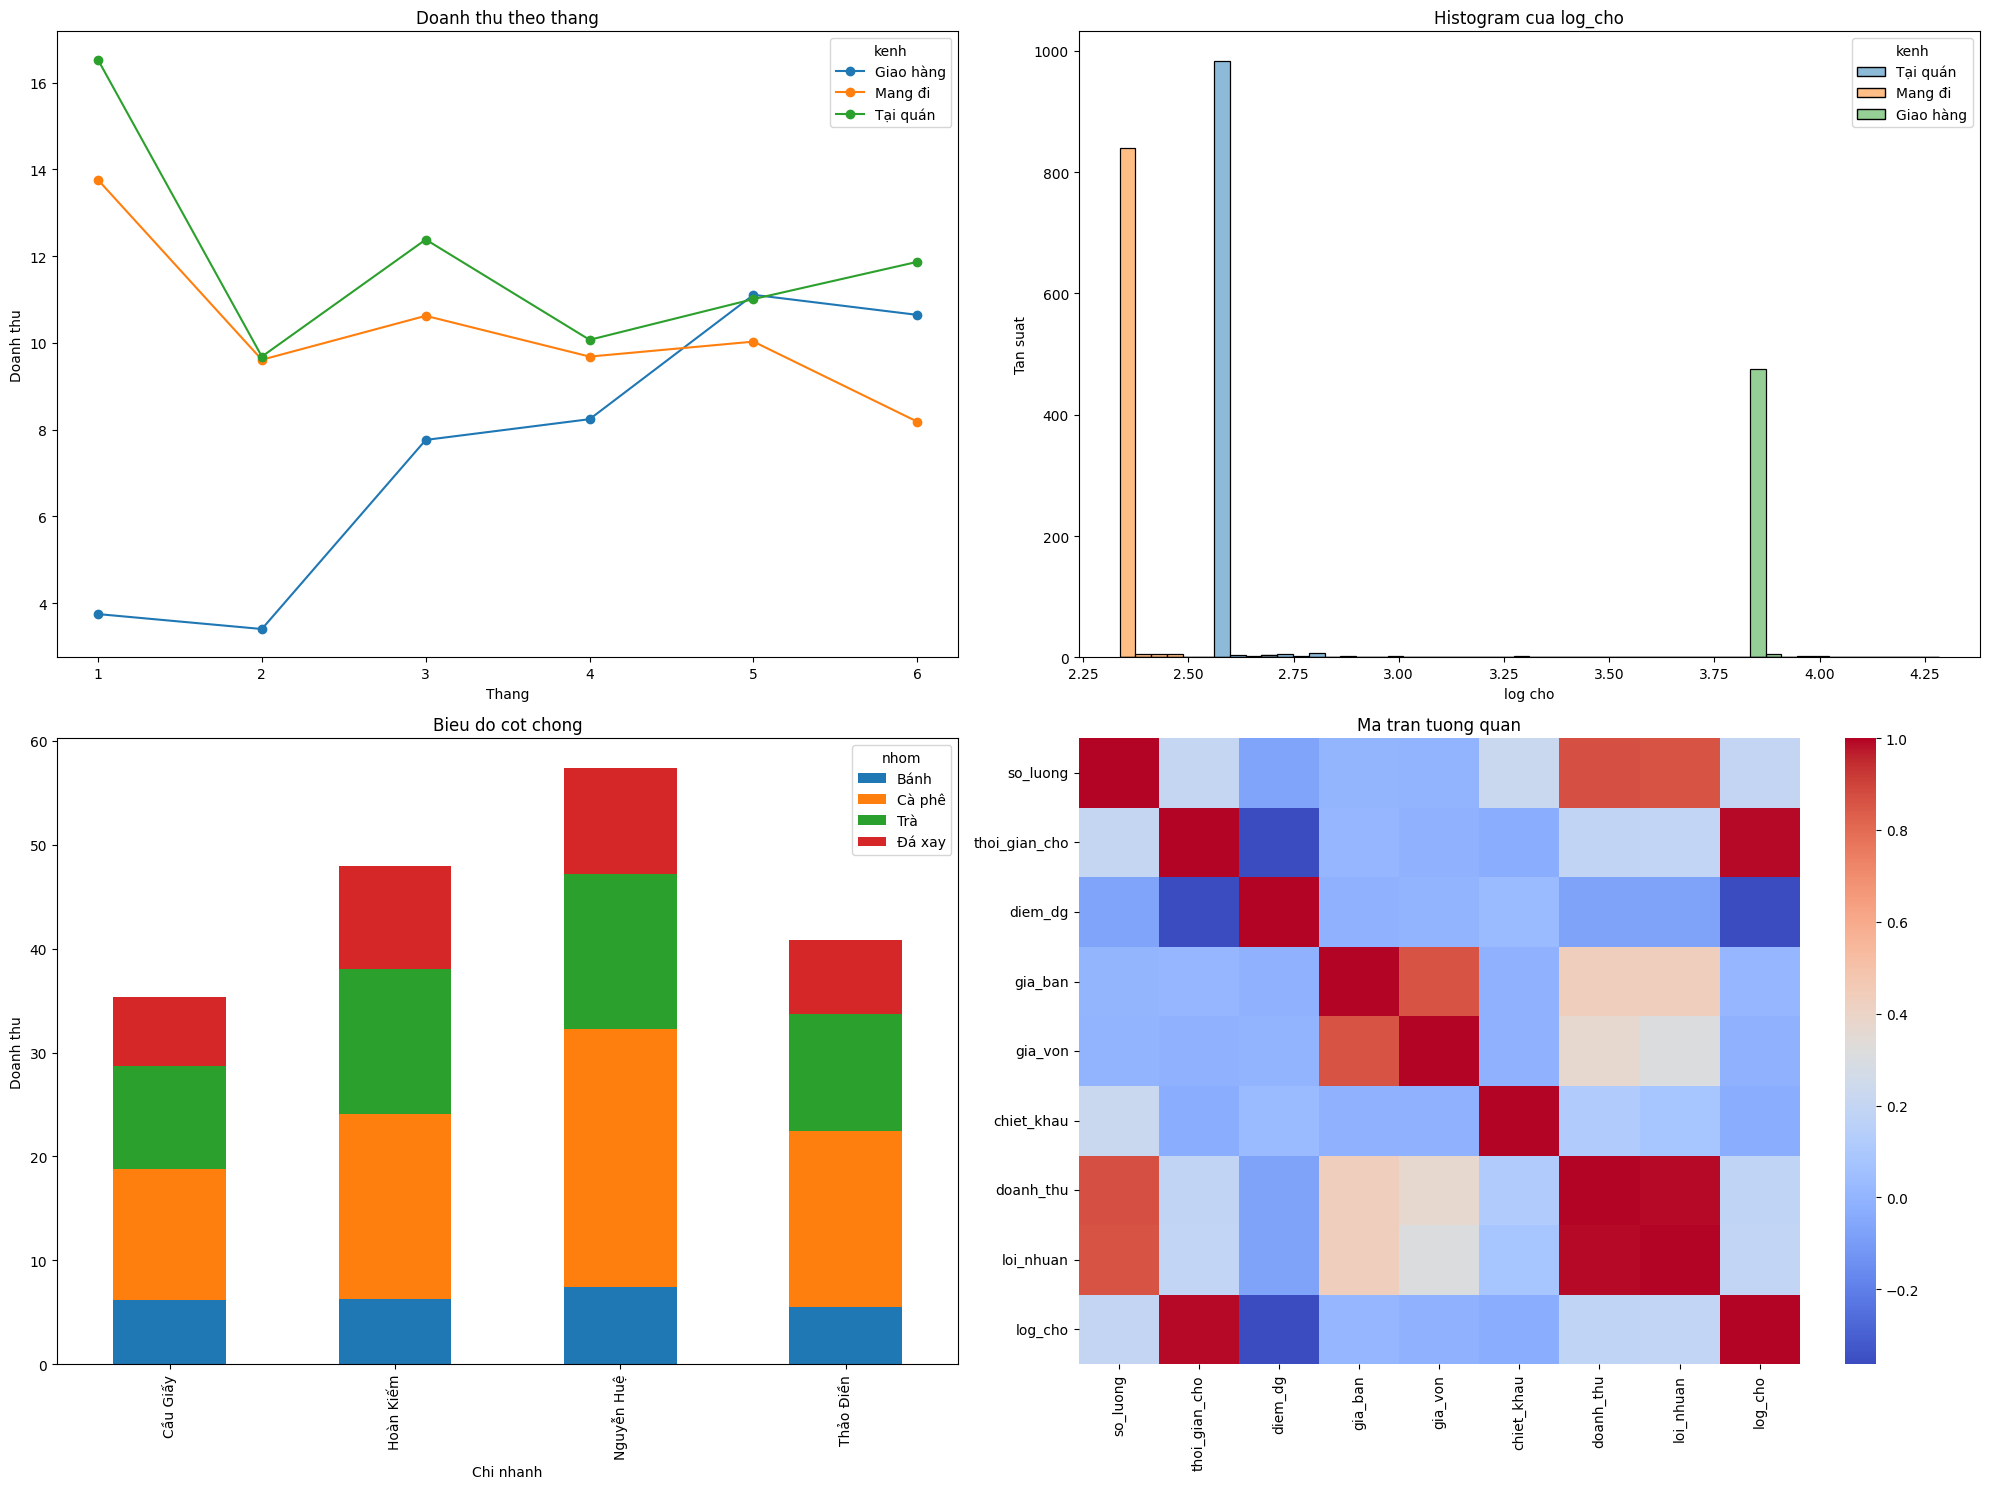

In [22]:
fig, axes = plt.subplots(2,2, figsize=(20,15))
theo_thang = (table.groupby([df['thoi_gian'].dt.month, 'kenh'])['doanh_thu'].sum() / 1e6).unstack()
theo_thang.plot(ax=axes[0,0], marker='o')
axes[0,0].set(title='Doanh thu theo thang', xlabel='Thang', ylabel='Doanh thu')

sns.histplot(data=table, x='log_cho', hue='kenh', ax=axes[0,1])
axes[0,1].set(title='Histogram cua log_cho', xlabel='log cho', ylabel='Tan suat')

pv = table.pivot_table(index='ten_cn', columns='nhom', values='doanh_thu', aggfunc='sum') / 1e6
pv.plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set(title='Bieu do cot chong', xlabel='Chi nhanh', ylabel='Doanh thu')

sns.heatmap(correlation, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set(title='Ma tran tuong quan')

fig.tight_layout()
fig.savefig('ket_qua.png', dpi=150)
fig.show()

**Nhận xét E:** …